VGG16 loaded.

       Layer      RF       1/RF           SumSq
────────────────────────────────────────────────
     conv1_1       3    0.33333          108.73
     conv1_2       5    0.20000          115.06
     conv2_1      10    0.10000          182.04
     conv2_2      14    0.07143          218.73
     conv3_1      24    0.04167          298.33
     conv3_2      32    0.03125          356.08
     conv3_3      40    0.02500          379.88
     conv4_1      60    0.01667          550.04
     conv4_2      76    0.01316          633.56
     conv4_3      92    0.01087          630.50
     conv5_1     132    0.00758          709.11
     conv5_2     164    0.00610          682.91
     conv5_3     196    0.00510          610.70

Power-law fit:  SumSq  =  6.081e+01  ×  (1/L)^-0.495
R² = 0.9597,  p = 5.1104e-09


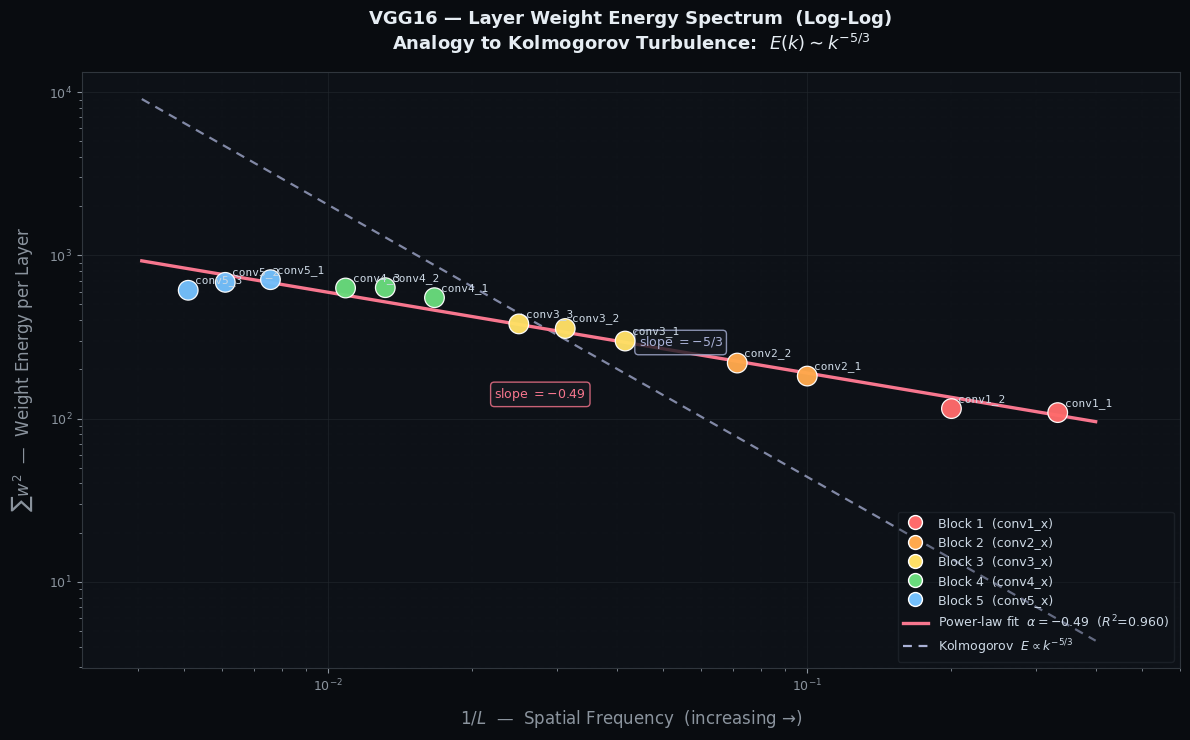


Saved → vggnet_loglog_turbulence.png
Power-law exponent α = -0.4947  (Kolmogorov prediction = -5/3 ≈ -1.667)


In [ ]:
# ============================================================
# VGGNet: Weight Sum-of-Squares vs 1/Receptive Field
#   • Log-Log scale
#   • Power-law fit  (E ~ (1/L)^α)
#   • Kolmogorov -5/3 turbulence reference line
#   • X-axis: increasing 1/L  (small RF → large RF left to right)
# ============================================================

# !pip install torch torchvision matplotlib numpy scipy --quiet

import torch
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import linregress

# ──────────────────────────────────────────────────────────────
# 1. Load Pretrained VGG16
# ──────────────────────────────────────────────────────────────
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.eval()
print("VGG16 loaded.\n")

# ──────────────────────────────────────────────────────────────
# 2. Receptive Field per Conv Layer
# ──────────────────────────────────────────────────────────────
def vgg16_receptive_fields():
    """
    Iterative RF calculation:
        RF  ← RF + (k-1) * cumulative_stride
        stride ← stride * s   (only for pool layers)
    Returns layer names and RF sizes (in input pixels).
    """
    layers = [
        ('conv',3,1),('conv',3,1),('pool',2,2),
        ('conv',3,1),('conv',3,1),('pool',2,2),
        ('conv',3,1),('conv',3,1),('conv',3,1),('pool',2,2),
        ('conv',3,1),('conv',3,1),('conv',3,1),('pool',2,2),
        ('conv',3,1),('conv',3,1),('conv',3,1),('pool',2,2),
    ]
    rf, stride = 1, 1
    names, rfs = [], []
    blk, bidx = 1, 1
    for t, k, s in layers:
        if t == 'pool':
            rf += (k-1)*stride; stride *= s; blk += 1; bidx = 1
        else:
            rf += (k-1)*stride
            names.append(f"conv{blk}_{bidx}"); rfs.append(rf); bidx += 1
    return names, rfs

conv_names, receptive_fields = vgg16_receptive_fields()

# ──────────────────────────────────────────────────────────────
# 3. Sum of Squares of Weights per Conv Layer
# ──────────────────────────────────────────────────────────────
conv_layers = [m for m in model.features if isinstance(m, torch.nn.Conv2d)]
assert len(conv_layers) == len(receptive_fields)

weight_ss = [(layer.weight.data**2).sum().item() for layer in conv_layers]

print(f"{'Layer':>12}  {'RF':>6}  {'1/RF':>9}  {'SumSq':>14}")
print("─"*48)
for n, rf, ss in zip(conv_names, receptive_fields, weight_ss):
    print(f"{n:>12}  {rf:>6}  {1/rf:>9.5f}  {ss:>14.2f}")

# ──────────────────────────────────────────────────────────────
# 4. Arrays for plotting
# ──────────────────────────────────────────────────────────────
inv_rf  = np.array([1.0/r for r in receptive_fields])   # 1/L  (x-axis)
ss_arr  = np.array(weight_ss)                            # E(k) analogue

# ──────────────────────────────────────────────────────────────
# 5. Power-law fit:  log(SS) = α·log(1/L) + log(C)
#    i.e.  SS = C · (1/L)^α
# ──────────────────────────────────────────────────────────────
log_x = np.log10(inv_rf)
log_y = np.log10(ss_arr)
slope, intercept, r, p, se = linregress(log_x, log_y)
alpha = slope
C     = 10**intercept
print(f"\nPower-law fit:  SumSq  =  {C:.3e}  ×  (1/L)^{alpha:.3f}")
print(f"R² = {r**2:.4f},  p = {p:.4e}")

# Dense x grid for smooth fit curve
x_fit = np.logspace(np.log10(inv_rf.min()*0.8), np.log10(inv_rf.max()*1.2), 300)
y_fit = C * x_fit**alpha

# ──────────────────────────────────────────────────────────────
# 6. Kolmogorov -5/3 reference line
#    E(k) ~ k^(-5/3)  ↔  anchored at centroid of data
# ──────────────────────────────────────────────────────────────
x_kolm  = x_fit
x_anchor = np.exp(np.mean(np.log(inv_rf)))   # geometric mean of data x
y_anchor = C * x_anchor**alpha               # sit on the fitted curve
y_kolm   = y_anchor * (x_kolm / x_anchor)**(-5/3)

# ──────────────────────────────────────────────────────────────
# 7. Block colours
# ──────────────────────────────────────────────────────────────
palette = {
    'conv1': '#FF6B6B',
    'conv2': '#FFA94D',
    'conv3': '#FFE066',
    'conv4': '#69DB7C',
    'conv5': '#74C0FC',
}
colors = [palette[n[:5]] for n in conv_names]

# ──────────────────────────────────────────────────────────────
# 8. Plot
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7.5))
fig.patch.set_facecolor('#090C10')
ax.set_facecolor('#0D1117')

# ── Kolmogorov reference ──
ax.plot(x_kolm, y_kolm,
        color='#A9B1D6', linewidth=1.6, linestyle=(0,(4,3)),
        label=r'Kolmogorov  $E \propto k^{-5/3}$', zorder=2, alpha=0.75)

# ── Power-law fit ──
ax.plot(x_fit, y_fit,
        color='#F7768E', linewidth=2.4, linestyle='-',
        label=fr'Power-law fit  $\propto (1/L)^{{{alpha:.2f}}}$  ($R^2$={r**2:.3f})',
        zorder=3)

# ── Data ──
ax.scatter(inv_rf, ss_arr,
           c=colors, s=200, zorder=5, edgecolors='white',
           linewidths=0.9, alpha=0.97)

# ── Annotate ──
for i, name in enumerate(conv_names):
    ax.annotate(name,
                xy=(inv_rf[i], ss_arr[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color='#CDD9E5', fontfamily='monospace', zorder=6)

# ── Axes: LOG-LOG ──
ax.set_xscale('log')
ax.set_yscale('log')

# x-axis: increasing 1/L  (left = small 1/L = large L, right = large 1/L = small L)
ax.set_xlim(inv_rf.min()*0.6, inv_rf.max()*1.8)

# ── Slope annotation box ──
mid_x = np.sqrt(x_fit[0]*x_fit[-1])
mid_y_kolm = y_anchor * (mid_x / x_anchor)**(-5/3)
ax.annotate(r'slope $= -5/3$',
            xy=(mid_x*1.1, mid_y_kolm*1.4),
            fontsize=9, color='#A9B1D6',
            bbox=dict(boxstyle='round,pad=0.3', fc='#161B22', ec='#A9B1D6', alpha=0.8))

mid_y_fit = C * mid_x**alpha
ax.annotate(fr'slope $= {alpha:.2f}$',
            xy=(mid_x*0.55, mid_y_fit*0.45),
            fontsize=9, color='#F7768E',
            bbox=dict(boxstyle='round,pad=0.3', fc='#161B22', ec='#F7768E', alpha=0.8))

# ── Ticks & Grid ──
ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(base=10))
ax.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(base=10))
ax.tick_params(colors='#8B949E', which='both', labelsize=9)
ax.grid(True, which='major', linestyle='-',  linewidth=0.5, color='#21262D', alpha=0.9)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#21262D', alpha=0.6)
for spine in ax.spines.values():
    spine.set_edgecolor('#30363D')

# ── Block legend ──
from matplotlib.lines import Line2D
block_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=c,
           markersize=10, linewidth=0, label=f'Block {i+1}  (conv{i+1}_x)')
    for i,(blk,c) in enumerate(palette.items())
]
fit_handles = [
    Line2D([0],[0], color='#F7768E', linewidth=2.4,
           label=fr'Power-law fit  $\alpha={alpha:.2f}$  ($R^2$={r**2:.3f})'),
    Line2D([0],[0], color='#A9B1D6', linewidth=1.6, linestyle=(0,(4,3)),
           label=r'Kolmogorov  $E \propto k^{-5/3}$'),
]
leg = ax.legend(handles=block_handles + fit_handles,
                loc='lower right', fontsize=9,
                framealpha=0.25, labelcolor='#CDD9E5',
                facecolor='#0D1117', edgecolor='#444C56')

# ── Labels & Title ──
ax.set_xlabel(r'$1/L$  —  Spatial Frequency  (increasing →)',
              fontsize=12, color='#8B949E', labelpad=10)
ax.set_ylabel(r'$\sum w^2$  —  Weight Energy per Layer',
              fontsize=12, color='#8B949E', labelpad=10)
ax.set_title(
    'VGG16 — Layer Weight Energy Spectrum  (Log-Log)\n'
    r'Analogy to Kolmogorov Turbulence:  $E(k) \sim k^{-5/3}$',
    fontsize=13, color='#E6EDF3', pad=16, fontweight='bold')

plt.tight_layout()
plt.savefig('vggnet_loglog_turbulence.png', dpi=150,
            bbox_inches='tight', facecolor='#090C10')
plt.show()
print(f"\nSaved → vggnet_loglog_turbulence.png")
print(f"Power-law exponent α = {alpha:.4f}  (Kolmogorov prediction = -5/3 ≈ -1.667)")